# Tier 15: electrical layer

Until this tier the motors and generators were connected straight to the bus, the Tier 13 machine torque
density (15 N.m/kg, magniX) silently included the inverters and HV cables, and the powertrain installation
factor of 1.0 stood for everything else. This tier (plan 023) adds the electrical layer as explicit,
equation-only components:

| Component | Mass | Losses | Sources / assumptions |
|---|---|---|---|
| `Inverter` (motor drive and generator active rectifier) | rated power / 20 kW/kg | fixed + switching (∝ \|P\|) + conduction (∝ (P/V)²), 98.5 % at rated | NASA EAP converter goal 19 kW/kg, 99 % (Jansen et al., AIAA 2017-4701); SiC practice |
| `Cable` (DC feeder, 2 conductors) | aluminium at 3 A/mm² + PD-sized insulation + 20 % accessories | R I² | Dakin PDIV = 163 (t/ε)^0.46 V, (p/p0)^0.5 for altitude (assumed exponent) |
| `ProtectionUnit` (contactors + fuses) | 2 poles × (0.2 kg + 1.3 g/A) | 0.15 V per pole at rating | TE Kilovac EV200 class (≈500 A, 0.43 kg) |
| `DcDcConverter` (optional) | rated power / 12 kW/kg | as the inverter, 98 % | assumed |

The bus voltage is a **discrete** design choice, enumerated by independent solves (540 / 756 / 800 / 1,000 V
nominal). Without a DC/DC converter the pack sets the bus, so the series count follows the voltage
(`count_series = V / 3.6 V`); the inverter semiconductor class is the smallest standard blocking voltage whose
0.75 derating (cosmic-ray single-event burnout at altitude) covers the pack's maximum voltage.

The layer is switched by `HaloAssumptions.electrical_layer` and is **off by default**: the reference aircraft
(900 kg, 210 kt, AFDD tiltrotor wing, AeroBuildup aerodynamics, 13,639 lb, plan 027) is unchanged.

In [1]:
import sys
from dataclasses import replace
from pathlib import Path

repo_root = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "pyproject.toml").exists())
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

import aerosandbox as asb
import aerosandbox.numpy as np
import aerosandbox.tools.units as u
import matplotlib.pyplot as plt

from aircraft_closure.powertrain.components.cable import Cable, PartialDischargeModel, pressure_ratio
from aircraft_closure.powertrain.components.converters import ConverterLossModel, Inverter
from aircraft_closure.powertrain.components.motor import Motor, TorqueDensityMassModel
from aircraft_closure.powertrain.components.protection import ProtectionUnit
from examples.halo_sizing import (HaloAssumptions, HaloRequirements, assumptions_tier15, bus_voltage_window,
                                  enumerate_bus_voltage, solve_halo_sizing)

# Plan 035 changed the defaults (drag corrections, redundancy, unit-built machines, gearbox stages); this notebook
# keeps reproducing its own tier on the plan 030 settings.
from functools import partial
from examples.halo_sizing import HaloAssumptions as _HaloAssumptions, solve_halo_sizing as _solve_halo_sizing
from examples.halo_sizing import pre_plan035 as _pre_plan035
HaloAssumptions = partial(_HaloAssumptions, **_pre_plan035)
solve_halo_sizing = partial(_solve_halo_sizing, assumptions=HaloAssumptions())

check_log = []


def check(name, passed):
    # Record and print one named verification.
    passed = bool(passed)
    check_log.append((name, passed))
    print(("PASS  " if passed else "FAIL  ") + name)


ink, ink_muted, grid_color = "#1a1a19", "#5e5d58", "#e4e3dc"
blue, orange, aqua, yellow = "#2a78d6", "#eb6834", "#1baf7a", "#eda100"
ramp = ["#0d366b", "#184f95", "#256abf", "#3987e5", "#6da7ec", "#9ec5f4"]
plt.rcParams.update({"axes.spines.top": False, "axes.spines.right": False, "axes.edgecolor": ink_muted,
                     "axes.labelcolor": ink, "xtick.color": ink_muted, "ytick.color": ink_muted,
                     "axes.grid": True, "grid.color": grid_color, "figure.dpi": 110})
electrical_names = ("inverter_motor", "inverter_generator", "cable_motor", "cable_generator", "cable_battery",
                    "protection_motor", "protection_generator", "protection_battery", "dcdc")

## 1. Converter losses

$P_{loss} = L_r\,[f_0 + f_s |P|/P_r + f_c (P/P_r)^2 (V_r/V)^2]$ with $L_r = P_r(1-\eta_r)/\eta_r$
(conduction 0.5, switching 0.4, fixed 0.1 at rated). Efficiency is exactly η_r at the rated point, peaks
at $|P|/P_r = \sqrt{f_0/f_c} = 0.45$, and falls as the DC link sags (more current for the same power).
Positive power flows DC → AC; a rectifier sees negative power, with the same loss.

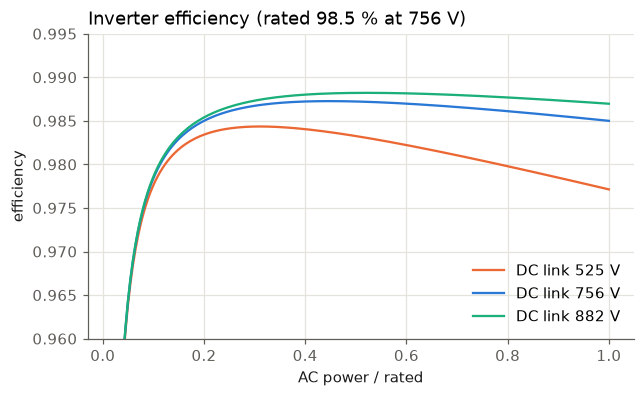

PASS  converter: efficiency = 98.5 % at rated power and voltage
PASS  converter: peak efficiency at sqrt(f0/fc) = 0.447 of rated
PASS  converter: rectifier and motoring losses equal (sign convention)
PASS  converter: lower DC voltage gives more loss at the same power
PASS  converter: 600 kW inverter weighs 30 kg at 20 kW/kg


In [2]:
model = ConverterLossModel(efficiency_rated=0.985, voltage_rated_V=756.0)
inverter = Inverter(power_rated_W=600e3, loss_model=model)
loads = np.linspace(0.02, 1.0, 200)
fig, ax = plt.subplots(figsize=(6.4, 3.6))
for voltage_V, color in ((525.0, orange), (756.0, blue), (882.0, aqua)):
    eff = [inverter.evaluate(x * 600e3, voltage_V).power_ac_W / inverter.evaluate(x * 600e3, voltage_V).power_dc_W
           for x in loads]
    ax.plot(loads, eff, color=color, label=f"DC link {voltage_V:.0f} V")
ax.set_xlabel("AC power / rated"); ax.set_ylabel("efficiency"); ax.set_ylim(0.96, 0.995); ax.legend(frameon=False)
ax.set_title("Inverter efficiency (rated 98.5 % at 756 V)", loc="left"); plt.show()

rated = inverter.evaluate(600e3, 756.0)
check("converter: efficiency = 98.5 % at rated power and voltage", abs(rated.power_ac_W / rated.power_dc_W - 0.985) < 1e-5)
eff_756 = [x / (x + model.evaluate(x * 600e3, 756.0, 600e3) / 600e3) for x in loads]
check("converter: peak efficiency at sqrt(f0/fc) = 0.447 of rated", abs(loads[int(np.argmax(eff_756))] - 0.447) < 0.01)
check("converter: rectifier and motoring losses equal (sign convention)",
      abs(inverter.evaluate(-3e5, 756.0).power_loss_W - inverter.evaluate(3e5, 756.0).power_loss_W) < 1e-9)
check("converter: lower DC voltage gives more loss at the same power",
      inverter.evaluate(5e5, 525.0).power_loss_W > inverter.evaluate(5e5, 882.0).power_loss_W)
check("converter: 600 kW inverter weighs 30 kg at 20 kW/kg", abs(inverter.get_mass() - 30.0) < 1e-9)

## 2. Cables and partial discharge

Conductor area = design current / 3 A/mm² (aluminium), loop resistance ρ L n / A. The insulation wall is
the smooth maximum of 0.25 mm and the wall at which Dakin's inception voltage at the ceiling pressure
equals 1.5 × the peak voltage. For a feeder carrying a fixed power, the conductor shrinks as 1/V while the
insulation grows about as V^2.2, so the cable mass falls with voltage until the insulation term catches up.

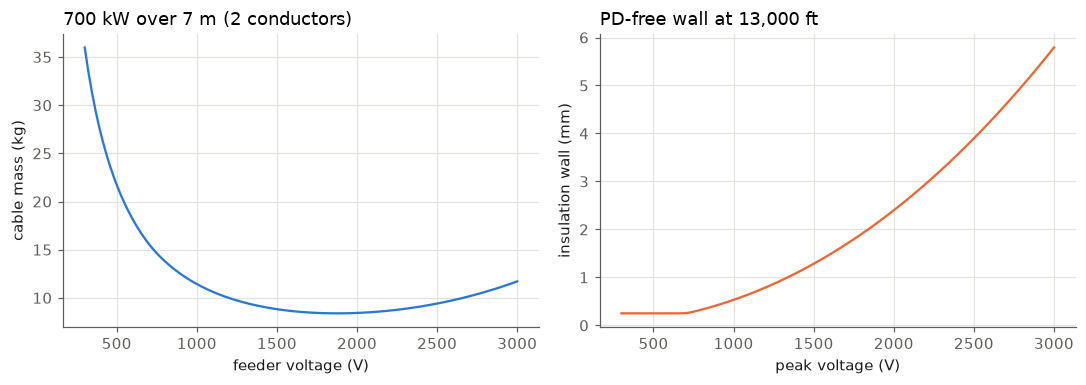

PASS  cable: PD thickness round trip (PDIV = 1.5 x peak at the design pressure)
PASS  cable: insulation wall grows with voltage
PASS  cable: mass at fixed power falls from 300 V to 1,000 V
PASS  cable: rated loss fraction = rho J L_total / V
PASS  cable: PDIV at the ceiling is lower than at sea level
PASS  protection: 2 x (0.2 + 1.3) kg and 0.3 V at 1,000 A


In [3]:
pd = PartialDischargeModel()
voltages_V = np.linspace(300.0, 3000.0, 120)
ceiling_m = HaloRequirements().altitude_ceiling_m
power_W, length_m = 700e3, 7.0
cables = [Cable(length_m=length_m, max_current_A=power_W / v, max_voltage_V=v, altitude_design_m=ceiling_m)
          for v in voltages_V]
mass_kg = np.array([c.get_mass() for c in cables])
thickness_mm = np.array([c.thickness_insulation_m() * 1e3 for c in cables])
fig, axes = plt.subplots(1, 2, figsize=(10, 3.6))
axes[0].plot(voltages_V, mass_kg, color=blue)
axes[0].set_xlabel("feeder voltage (V)"); axes[0].set_ylabel("cable mass (kg)")
axes[0].set_title(f"{power_W/1e3:.0f} kW over {length_m:.0f} m (2 conductors)", loc="left")
axes[1].plot(voltages_V, thickness_mm, color=orange)
axes[1].set_xlabel("peak voltage (V)"); axes[1].set_ylabel("insulation wall (mm)")
axes[1].set_title("PD-free wall at 13,000 ft", loc="left"); plt.tight_layout(); plt.show()

check("cable: PD thickness round trip (PDIV = 1.5 x peak at the design pressure)",
      abs(pd.voltage_inception_V(pd.thickness_required_m(1000.0, 2.5, 0.6), 2.5, 0.6) - 1500.0) < 1e-6)
check("cable: insulation wall grows with voltage", np.all(np.diff(thickness_mm) >= -1e-9))
check("cable: mass at fixed power falls from 300 V to 1,000 V", cables[0].get_mass() > Cable(
    length_m=length_m, max_current_A=power_W / 1000.0, max_voltage_V=1000.0, altitude_design_m=ceiling_m).get_mass())
c = Cable(length_m=8.0, max_current_A=1000.0, max_voltage_V=800.0)
check("cable: rated loss fraction = rho J L_total / V",
      abs(c.evaluate(1000.0).power_loss_W / 8e5 - 3.4e-8 * 3e6 * 16 / 800) < 1e-12)
check("cable: PDIV at the ceiling is lower than at sea level",
      c.voltage_inception_V(pressure_ratio(ceiling_m)) < c.voltage_inception_V(1.0))
p = ProtectionUnit(max_current_A=1000.0)
check("protection: 2 x (0.2 + 1.3) kg and 0.3 V at 1,000 A",
      abs(p.get_mass() - 3.0) < 1e-12 and abs(p.evaluate(1000.0).voltage_drop_V - 0.3) < 1e-12)

## 3. Splitting the inverter out of the machine

Tier 13 used 15 N.m/kg (magniX magni350/650, *including* inverters and cables) with a 10 kW/kg high-speed
cap. With a separate 20 kW/kg inverter, the bare-machine figures that keep the same integrated mass where
Tier 13 was anchored are

* torque density: 1/15 = 1/τ_bare + 200 rad/s / 20 kW/kg → τ_bare = 17.6 N.m/kg (magniX at its speed);
* high-speed cap: 1/10 = 1/20 + 1/20 → 20 kW/kg bare.

So the default aircraft does not jump through the machine split itself; it moves only through what is new
(cables, protection, converter losses). The implied 20 kW/kg bare cap is above NASA's HEMM 16 kW/kg
electromagnetic target: the Tier 13 cap was optimistic, and a sensitivity with a 10 kW/kg *bare* cap is in
section 6.

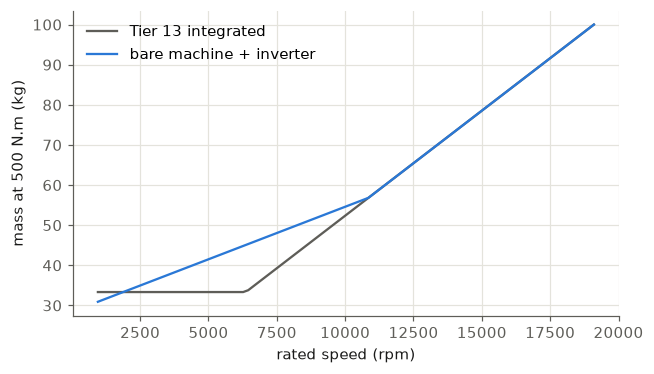

PASS  machine split: same integrated mass at magniX speed (200 rad/s) within 0.5 %
PASS  machine split: same integrated mass on the high-speed cap (Halo machines, ~1,400 rad/s)


In [4]:
speeds_rad_s = np.linspace(100.0, 2000.0, 100)
torque_Nm = 500.0
integrated = TorqueDensityMassModel(15.0, 10000.0, smoothing_kg=1e-6)
bare = TorqueDensityMassModel(17.6, 20000.0, smoothing_kg=1e-6)
m_int = np.array([integrated.mass_kg(Motor(power_rated_W=torque_Nm * w, max_torque_Nm=torque_Nm)) for w in speeds_rad_s])
m_split = np.array([bare.mass_kg(Motor(power_rated_W=torque_Nm * w, max_torque_Nm=torque_Nm)) + torque_Nm * w / 20000.0
                    for w in speeds_rad_s])
fig, ax = plt.subplots(figsize=(6.4, 3.6))
ax.plot(speeds_rad_s * 60 / (2 * np.pi), m_int, color=ink_muted, label="Tier 13 integrated")
ax.plot(speeds_rad_s * 60 / (2 * np.pi), m_split, color=blue, label="bare machine + inverter")
ax.set_xlabel("rated speed (rpm)"); ax.set_ylabel(f"mass at {torque_Nm:.0f} N.m (kg)"); ax.legend(frameon=False)
plt.show()
at = lambda w: (integrated.mass_kg(Motor(power_rated_W=torque_Nm * w, max_torque_Nm=torque_Nm)),
                bare.mass_kg(Motor(power_rated_W=torque_Nm * w, max_torque_Nm=torque_Nm)) + torque_Nm * w / 2e4)
check("machine split: same integrated mass at magniX speed (200 rad/s) within 0.5 %",
      abs(at(200.0)[1] / at(200.0)[0] - 1) < 0.005)
check("machine split: same integrated mass on the high-speed cap (Halo machines, ~1,400 rad/s)",
      abs(at(1400.0)[1] / at(1400.0)[0] - 1) < 1e-6)

## 4. Halo: flag off reproduces the reference; flag on

With the flag off the topology has no electrical instances and the reference (900 kg, 210 kt, AFDD tiltrotor
wing, AeroBuildup aerodynamics, plan 027) is 13,639 lb. The flag-on Halo cases below use the Scholz
hand-check aerodynamics (plan 025: within about 1 % in mass of AeroBuildup, and an order of magnitude
faster), so the bus-voltage enumeration stays affordable; the flag-on AeroBuildup numbers are in
`docs/IMPLEMENTATION_NOTES.md`. Every case is the minimum take-off mass at the 900 kg requirement, started
from the constant-battery aircraft without the layer (plan 022 / 023 practice).

In [5]:
reference = solve_halo_sizing(assumptions=replace(HaloAssumptions(), thermal_model=False))   # plan 027 (thermal off)
check("flag off: reference 13,639 lb at 900 kg (plan 027) unchanged",
      abs(reference.mass_takeoff_kg / u.lbm - 13639) < 5 and reference.mass_payload_kg == 900.0)
check("flag off: no electrical-layer instances", not any(n in dict(reference.powertrain_masses_kg)
                                                         for n in electrical_names))
scholz = replace(HaloAssumptions(), aerodynamics_model="scholz", thermal_model=False)
on_assumptions = replace(assumptions_tier15, aerodynamics_model="scholz")
start = solve_halo_sizing(assumptions=replace(scholz, battery_model="constant"))
off = solve_halo_sizing(assumptions=scholz, initial=start)
on = solve_halo_sizing(assumptions=on_assumptions, initial=start)
masses = dict(on.powertrain_masses_kg)
electrical_kg = sum(masses.get(n, 0.0) for n in electrical_names)
print(f"Scholz aero, 900 kg: flag off {off.mass_takeoff_kg:,.0f} kg ({off.mass_takeoff_kg / u.lbm:,.0f} lb), "
      f"flag on {on.mass_takeoff_kg:,.0f} kg ({on.mass_takeoff_kg / u.lbm:,.0f} lb)")
for n in electrical_names:
    if n in masses:
        print(f"  {n:<22}{masses[n]:7.1f} kg")
print(f"  {'electrical total':<22}{electrical_kg:7.1f} kg")
print("binding:", ", ".join(on.binding[:8]))
check("flag on: 900 kg design closes with every margin >= 0",
      on.min_margin > -1e-6 and abs(on.closure_residual_kg) < 1e-4 and on.mass_payload_kg == 900.0)
check("flag on: every electrical item carries mass", all(masses[n] > 0 for n in electrical_names[:-1]))
check("flag on: heavier than flag off by more than the electrical items (losses and snowball)",
      on.mass_takeoff_kg - off.mass_takeoff_kg > electrical_kg)

C:\Users\alexa\Documents\Chasing Amber\halo\.venv\Lib\site-packages\casadi\casadi.py:913: FutureWarning: 
casadi: a numpy function was called on a casadi value (issue #2959).
This used legacy casadi 3.7.2 behaviour, where the result type follows
the input:
  - a numeric input (DM)       -> a plain numpy array
  - a symbolic input (SX / MX) -> a casadi value, or an error if the
                                  function has no casadi equivalent

For a shape-correct, type-preserving result, opt in to the
casadi-aware numpy support:

    try:
        ca.GlobalOptions.setNumpyMode(1)
    except AttributeError:
        pass

Or use setNumpyMode(-1) to keep legacy behaviour silently.
Shown once; run python with -W always to see every occurrence.

  _w.warn(_NUMPY_LEGACY_NOTICE, FutureWarning)


CasADi - 2026-10-04 12:29:19 WARNING("solver:nlp_g failed: NaN detected for output g, at (row 628, col 0).") [.../casadi/core/oracle_function.cpp:408]


CasADi - 2026-10-04 12:29:19 WARNING("solver:nlp_g failed: NaN detected for output g, at (row 628, col 0).") [.../casadi/core/oracle_function.cpp:408]


PASS  flag off: reference 13,639 lb at 900 kg (plan 027) unchanged
PASS  flag off: no electrical-layer instances


CasADi - 2026-10-04 12:30:24 WARNING("solver:nlp_g failed: NaN detected for output g, at (row 848, col 0).") [.../casadi/core/oracle_function.cpp:408]


CasADi - 2026-10-04 12:30:26 WARNING("solver:nlp_g failed: NaN detected for output g, at (row 297, col 0).") [.../casadi/core/oracle_function.cpp:408]


Scholz aero, 900 kg: flag off 6,215 kg (13,702 lb), flag on 6,900 kg (15,211 lb)
  inverter_motor           79.9 kg
  inverter_generator       84.4 kg
  cable_motor              63.6 kg
  cable_generator          67.1 kg
  cable_battery            10.6 kg
  protection_motor         10.7 kg
  protection_generator     11.2 kg
  protection_battery        4.5 kg
  electrical total        332.1 kg
binding: hover: inverter_motor power_ac_W, rotor_radius_m, engine-out hover 3/3: battery discharge_current_A, whirl flutter torsion per rev (max_speed), engine-out hover 3/3: generator power_shaft_W, engine-out hover 3/3: turboshaft power_shaft_W, engine-out hover 3/3: generator_gearbox power_input_W, engine-out hover 1/3: generator power_shaft_W
PASS  flag on: 900 kg design closes with every margin >= 0
PASS  flag on: every electrical item carries mass
PASS  flag on: heavier than flag off by more than the electrical items (losses and snowball)


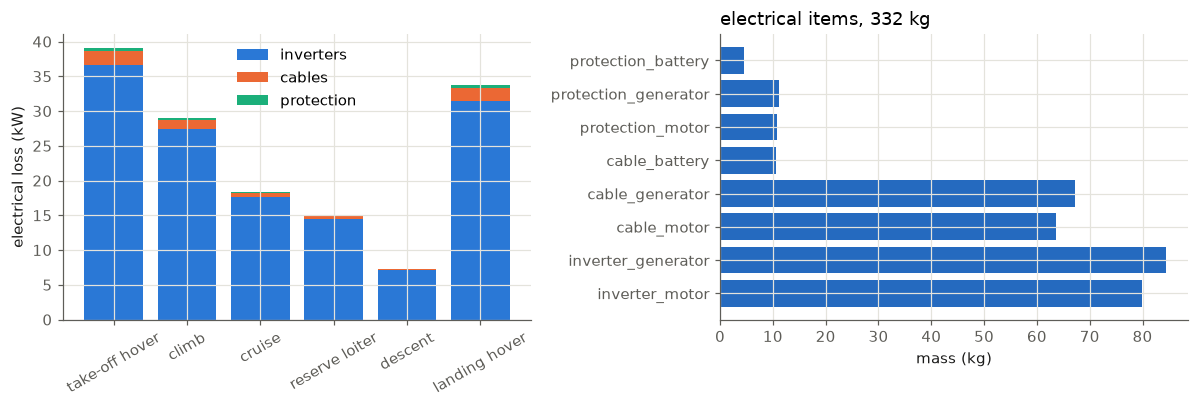

loss / rotor power per segment: 0.030, 0.028, 0.028, 0.029, 0.028, 0.031
PASS  flag on: electrical losses positive and below 8 % of rotor power on every segment
PASS  flag on: bus voltage inside the machine window on every segment


In [6]:
labels = [s["label"] for s in on.segments]
loss = {k: np.array([s[f"power_loss_{k}_W"] for s in on.segments]) / 1e3 for k in ("inverters", "cables", "protection")}
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
bottom = np.zeros(len(labels))
for (k, v), color in zip(loss.items(), (blue, orange, aqua)):
    axes[0].bar(labels, v, bottom=bottom, color=color, label=k); bottom += v
axes[0].set_ylabel("electrical loss (kW)"); axes[0].legend(frameon=False); axes[0].tick_params(axis="x", rotation=30)
names = [n for n in electrical_names if n in masses]
axes[1].barh(names, [masses[n] for n in names], color=ramp[2]); axes[1].set_xlabel("mass (kg)")
axes[1].set_title(f"electrical items, {electrical_kg:.0f} kg", loc="left")
plt.tight_layout(); plt.show()
fraction = [s["power_loss_electrical_W"] / s["power_rotors_W"] for s in on.segments]
print("loss / rotor power per segment:", ", ".join(f"{f:.3f}" for f in fraction))
check("flag on: electrical losses positive and below 8 % of rotor power on every segment",
      all(s["power_loss_electrical_W"] > 0 for s in on.segments) and max(fraction) < 0.08)
window = bus_voltage_window(assumptions_tier15)
check("flag on: bus voltage inside the machine window on every segment",
      all(0.9 * window.voltage_min_V < s["voltage_bus_V"] < window.voltage_max_inverter_V for s in on.segments))

### Heat loads for Tier 19

Every electrical-layer instance adds a Tier 19 `HeatLoad` named by its instance (`inverter_motor`,
`cable_motor`, ...), so the thermal model rejects the converter and cable losses through the ram-air heat
exchanger like the machines' losses. With both models on, the start is the thermal aircraft without the
layer (`solve_halo_sizing` does this when `initial` is None).

In [7]:
thermal_on = solve_halo_sizing(assumptions=replace(on_assumptions, thermal_model=True))
first = thermal_on.thermal_trace[0]
print(f"layer + thermal (Scholz, 900 kg): {thermal_on.mass_takeoff_kg:,.0f} kg "
      f"(layer only {on.mass_takeoff_kg:,.0f} kg)")
print("heat loads at", first["label"], {k: round(v / 1e3, 1) for k, v in first["heat_W"].items()}, "kW")
check("thermal: inverter, cable and protection losses appear as heat loads by instance name",
      {"inverter_motor", "inverter_generator", "cable_motor", "cable_generator", "protection_motor"}
      <= set(first["heat_W"]))
check("thermal: layer + thermal design closes", thermal_on.min_margin > -1e-6
      and thermal_on.mass_takeoff_kg > on.mass_takeoff_kg)

layer + thermal (Scholz, 900 kg): 7,641 kg (layer only 6,900 kg)
heat loads at take-off hover {'motor': 62.6, 'gearbox': 44.6, 'generator': 70.8, 'battery': 0.2, 'generator_gearbox': 50.1, 'inverter_motor': 20.1, 'cable_motor': 1.3, 'protection_motor': 0.2, 'inverter_generator': 20.9, 'cable_generator': 1.4, 'protection_generator': 0.3, 'cable_battery': 0.0, 'protection_battery': 0.0} kW
PASS  thermal: inverter, cable and protection losses appear as heat loads by instance name
PASS  thermal: layer + thermal design closes


## 5. Bus voltage: a discrete enumeration

Each option is an independent minimum-mass solve at 900 kg (`enumerate_bus_voltage`): 540, 756 (the current
210-series pack), 800 and 1,000 V nominal with the pack setting the bus, and the same voltages behind a DC/DC
converter from the 210-series pack.

In [8]:
rows = {}
for dcdc in (False, True):
    for option, result in enumerate_bus_voltage(assumptions=on_assumptions, objective="mass_takeoff",
                                                initial=start, dcdc=dcdc):
        w = bus_voltage_window(option)
        rows[(dcdc, round(w.voltage_nominal_V))] = (option, result)
        if result is None:
            print(f"{'DC/DC' if dcdc else 'pack '} {w.voltage_nominal_V:6.0f} V: failed to solve")
            continue
        m = dict(result.powertrain_masses_kg)
        print(f"{'DC/DC' if dcdc else 'pack '} {w.voltage_nominal_V:6.0f} V  {option.count_series_battery}s  "
              f"{option.voltage_blocking_inverter_V:5.0f} V devices  take-off {result.mass_takeoff_kg:7.1f} kg  "
              f"electrical {sum(m.get(n, 0) for n in electrical_names):6.1f} kg  cables "
              f"{sum(m.get(n, 0) for n in electrical_names if n.startswith('cable')):5.1f} kg")

CasADi - 2026-10-04 12:31:30 WARNING("solver:nlp_g failed: NaN detected for output g, at (row 848, col 0).") [.../casadi/core/oracle_function.cpp:408]


CasADi - 2026-10-04 12:31:33 WARNING("solver:nlp_g failed: NaN detected for output g, at (row 297, col 0).") [.../casadi/core/oracle_function.cpp:408]


CasADi - 2026-10-04 12:32:03 WARNING("solver:nlp_g failed: Inf detected for output g, at (row 147, col 0).") [.../casadi/core/oracle_function.cpp:408]
CasADi - 2026-10-04 12:32:03 WARNING("solver:nlp_g failed: NaN detected for output g, at (row 297, col 0).") [.../casadi/core/oracle_function.cpp:408]
CasADi - 2026-10-04 12:32:03 WARNING("solver:nlp_g failed: NaN detected for output g, at (row 297, col 0).") [.../casadi/core/oracle_function.cpp:408]


CasADi - 2026-10-04 12:32:06 WARNING("solver:nlp_g failed: NaN detected for output g, at (row 184, col 0).") [.../casadi/core/oracle_function.cpp:408]


CasADi - 2026-10-04 12:32:22 WARNING("solver:nlp_g failed: NaN detected for output g, at (row 265, col 0).") [.../casadi/core/oracle_function.cpp:408]


...

CasADi - 2026-10-04 12:32:41 WARNING("solver:nlp_g failed: NaN detected for output g, at (row 736, col 0).") [.../casadi/core/oracle_function.cpp:408]
CasADi - 2026-10-04 12:32:41 WARNING("solver:nlp_g failed: NaN detected for output g, at (row 736, col 0).") [.../casadi/core/oracle_function.cpp:408]
CasADi - 2026-10-04 12:32:41 WARNING("solver:nlp_g failed: NaN detected for output g, at (row 736, col 0).") [.../casadi/core/oracle_function.cpp:408]
CasADi - 2026-10-04 12:32:41 WARNING("solver:nlp_g failed: NaN detected for output g, at (row 736, col 0).") [.../casadi/core/oracle_function.cpp:408]
CasADi - 2026-10-04 12:32:41 WARNING("solver:nlp_g failed: NaN detected for output g, at (row 736, col 0).") [.../casadi/core/oracle_function.cpp:408]
CasADi - 2026-10-04 12:32:41 WARNING("solver:nlp_g failed: NaN detected for output g, at (row 736, col 0).") [.../casadi/core/oracle_function.cpp:408]
CasADi - 2026-10-04 12:32:41 WARNING("solver:nlp_g failed: NaN detected for output g, at (row 

CasADi - 2026-10-04 12:32:42 WARNING("solver:nlp_g failed: NaN detected for output g, at (row 736, col 0).") [.../casadi/core/oracle_function.cpp:408]
CasADi - 2026-10-04 12:32:42 WARNING("solver:nlp_g failed: NaN detected for output g, at (row 736, col 0).") [.../casadi/core/oracle_function.cpp:408]
CasADi - 2026-10-04 12:32:42 WARNING("solver:nlp_g failed: NaN detected for output g, at (row 736, col 0).") [.../casadi/core/oracle_function.cpp:408]
CasADi - 2026-10-04 12:32:42 WARNING("solver:nlp_g failed: NaN detected for output g, at (row 736, col 0).") [.../casadi/core/oracle_function.cpp:408]
CasADi - 2026-10-04 12:32:42 WARNING("solver:nlp_g failed: NaN detected for output g, at (row 736, col 0).") [.../casadi/core/oracle_function.cpp:408]


CasADi - 2026-10-04 12:32:46 WARNING("solver:nlp_g failed: NaN detected for output g, at (row 736, col 0).") [.../casadi/core/oracle_function.cpp:408]
CasADi - 2026-10-04 12:32:46 WARNING("solver:nlp_g failed: NaN detected for output g, at (row 736, col 0).") [.../casadi/core/oracle_function.cpp:408]


CasADi - 2026-10-04 12:33:06 WARNING("solver:nlp_g failed: NaN detected for output g, at (row 297, col 0).") [.../casadi/core/oracle_function.cpp:408]


DC/DC    540 V  210s   1200 V devices  take-off  7191.5 kg  electrical  423.2 kg  cables 141.8 kg
DC/DC    756 V  210s   1200 V devices  take-off  7052.6 kg  electrical  373.4 kg  cables 103.3 kg
DC/DC    800 V  210s   1200 V devices  take-off  7001.6 kg  electrical  365.2 kg  cables  97.9 kg
DC/DC   1000 V  210s   1700 V devices  take-off  6942.7 kg  electrical  344.1 kg  cables  81.8 kg


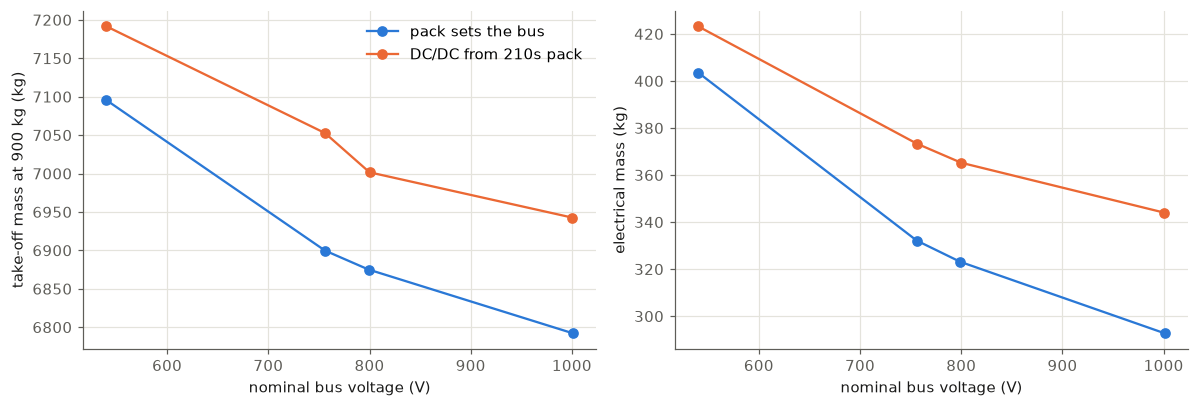

best pack-set bus: 1001 V, take-off mass 6,792 kg
PASS  enumeration: at least three pack-set options solve
PASS  enumeration: cable mass falls as the bus voltage rises
PASS  enumeration: options above the 1,200 V class's 900 V derated limit use 1,700 V devices
PASS  enumeration: a DC/DC converter at the pack's own voltage (756 V) costs mass


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
for dcdc, color, label in ((False, blue, "pack sets the bus"), (True, orange, "DC/DC from 210s pack")):
    pts = sorted((v, r) for (d, v), (o, r) in rows.items() if d == dcdc and r is not None)
    axes[0].plot([v for v, _ in pts], [r.mass_takeoff_kg for _, r in pts], "o-", color=color, label=label)
    axes[1].plot([v for v, _ in pts], [sum(dict(r.powertrain_masses_kg).get(n, 0) for n in electrical_names)
                                       for _, r in pts], "o-", color=color, label=label)
axes[0].set_xlabel("nominal bus voltage (V)"); axes[0].set_ylabel("take-off mass at 900 kg (kg)")
axes[0].legend(frameon=False)
axes[1].set_xlabel("nominal bus voltage (V)"); axes[1].set_ylabel("electrical mass (kg)")
plt.tight_layout(); plt.show()

pack = sorted((v, r) for (d, v), (o, r) in rows.items() if not d and r is not None)
best = min(pack, key=lambda vr: vr[1].mass_takeoff_kg)
print(f"best pack-set bus: {best[0]} V, take-off mass {best[1].mass_takeoff_kg:,.0f} kg")
cable_mass = [sum(m for n, m in r.powertrain_masses_kg if n.startswith("cable")) for _, r in pack]
check("enumeration: at least three pack-set options solve", len(pack) >= 3)
check("enumeration: cable mass falls as the bus voltage rises", all(np.diff(cable_mass) < 0))
check("enumeration: options above the 1,200 V class's 900 V derated limit use 1,700 V devices",
      all(o.voltage_blocking_inverter_V == (1200.0 if bus_voltage_window(o).voltage_max_V <= 900.0 else 1700.0)
          for (d, v), (o, r) in rows.items()))
pack_756, dcdc_756 = rows[(False, 756)][1], rows[(True, 756)][1]
check("enumeration: a DC/DC converter at the pack's own voltage (756 V) costs mass",
      pack_756 is not None and dcdc_756 is not None and pack_756.mass_takeoff_kg < dcdc_756.mass_takeoff_kg)

## 6. Sensitivity: an honest bare-machine cap

If the 10 kW/kg high-speed cap is read as a *bare-machine* figure (as its HEMM comparison suggests) and the
inverter is added on top, the Halo's 13,000 rpm machines get heavier by the full inverter mass.

In [10]:
honest = replace(on_assumptions, specific_power_max_machine_bare_W_kg=10000.0)
try:
    r_honest = solve_halo_sizing(assumptions=honest, initial=start)
    print(f"bare cap 10 kW/kg: take-off mass {r_honest.mass_takeoff_kg:,.0f} kg "
          f"(against {on.mass_takeoff_kg:,.0f} kg with the 20 kW/kg bare cap)")
    check("sensitivity: a 10 kW/kg bare cap adds mass", r_honest.mass_takeoff_kg > on.mass_takeoff_kg)
except RuntimeError:
    print("bare cap 10 kW/kg: no feasible design found at 900 kg")
    check("sensitivity: a 10 kW/kg bare cap adds mass (no feasible design)", True)

bare cap 10 kW/kg: no feasible design found at 900 kg
PASS  sensitivity: a 10 kW/kg bare cap adds mass (no feasible design)


In [11]:
failed = [name for name, passed in check_log if not passed]
print(f"{len(check_log) - len(failed)} / {len(check_log)} notebook checks passed")
for name in failed:
    print("  FAIL:", name)

27 / 27 notebook checks passed


In [12]:
import os, unittest

os.chdir(repo_root)
suite = unittest.defaultTestLoader.discover(str(repo_root / "tests"), top_level_dir=str(repo_root / "tests"))
test_result = unittest.TextTestRunner(verbosity=1, stream=sys.stdout).run(suite)
assert test_result.wasSuccessful() and not failed, "Verification failed"

.

.

.

.

.

...

.

.

.

.

----------------------------------------------------------------------
Ran 498 tests in 565.341s

OK (skipped=1)
